In [1]:
# Import necessary libraries for optical neural network simulation
import torch
from torch import nn
import svetlanna as sv

# Import units for physical measurements
from svetlanna.units import ureg

# Import MNIST dataset and data transformation utilities
from torchvision.datasets import MNIST
import torchvision.transforms as transforms
from svetlanna.transforms import ToWavefront

# Import visualization tools
import matplotlib.pyplot as plt
from svetlanna.visualization import show_stepwise_forward, show_structure, show_specs

# Convolutional Diffractive Network

# 1. Simulation parameters

This notebook is based on the article "Optical Diffractive Convolutional Neural Networks
Implemented in an All-Optical Way" [[1]](https://www.mdpi.com/1424-8220/23/12/5749).

> ... combining the 4f system as an optical convolutional layer and the diffractive networks

Since in [[1]](https://www.mdpi.com/1424-8220/23/12/5749) there are no details, we took physical parameters from another article [[2]](https://ieeexplore.ieee.org/abstract/document/8732486), which we used in some previous notebooks.

In [2]:
wavelength = 750 * ureg.um

c_const = 299_792_458 * ureg.m / ureg.s
frequency = c_const / wavelength
neuron_size = 375 * ureg.um

# Grid resolution
Nx = Ny = 200

# Physical dimensions of each diffractive layer
x_layer_size_m = Nx * neuron_size
y_layer_size_m = Ny * neuron_size

print(f'lambda    = {wavelength / ureg.um:.3f} um')
print(f'frequency = {frequency / ureg.THz:.3f} THz')
print(f'neuron size = {neuron_size * 1e6:.3f} um')
print(f'Layer size (in mm): {x_layer_size_m * 1e3 :.3f} x {y_layer_size_m * 1e3 :.3f}')

lambda    = 750.000 um
frequency = 0.400 THz
neuron size = 375.000 um
Layer size (in mm): 75.000 x 75.000


In [3]:
# Create simulation parameters for the optical system
# These parameters define the spatial grid and wavelength for all simulations
SIM_PARAMS = sv.SimulationParameters(
    {
        'W': torch.linspace(-x_layer_size_m / 2, x_layer_size_m / 2, Nx),
        'H': torch.linspace(-y_layer_size_m / 2, y_layer_size_m / 2, Ny),
        'wavelength': wavelength,
    }
)

# 2. Dataset preparation

> the input image of $28 \times 28$ pixels size was expanded to $200 \times 200$ with zero padding

In this example we will first scale the MNIST images to 100x100 pixels, and then pad them to 200x200 pixels.

In [4]:
# Define transformation pipeline for MNIST images
# 1. Convert to tensor
# 2. Scale to 100x100 pixels to fit within the central region of the diffractive layers
# 3. Pad to 200x200 to match the diffractive layer size
# 4. Convert to wavefront with amplitude modulation
to_wavefront_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Resize((100, 100)),  # Scale to 100x100 pixels
        transforms.Pad(
            padding=(50, 50, 50, 50),  # Pad equally on all sides
            fill=0,  # Fill with zeros (no light)
        ),
        ToWavefront(modulation_type="amp"),  # Encode in amplitude channel
    ]
)


# Load MNIST training dataset
training_data = MNIST(
    root="data",
    train=True,
    download=True,
    transform=to_wavefront_transform,
)

# Load MNIST test dataset
test_data = MNIST(
    root="data",
    train=False,
    download=True,
    transform=to_wavefront_transform,
)

print(f"Train data size: {len(training_data)}")
print(f"Test data size : {len(test_data)}")

Train data size: 60000
Test data size : 10000


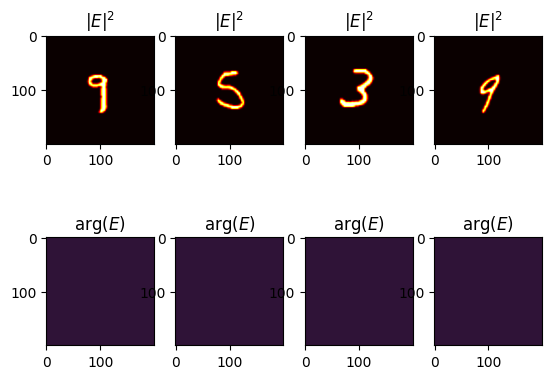

In [5]:
# Visualize some examples from the training dataset
n_examples = 4

torch.random.manual_seed(78)
train_examples_ids = torch.randperm(len(training_data))[:n_examples]

fig, axs = plt.subplots(2, n_examples)
for ind_ex, ind_train in enumerate(train_examples_ids):
    wavefront, wf_label = training_data[ind_train]

    # Show intensity (|E|^2)
    plt.subplot(2, n_examples, ind_ex + 1)
    plt.title("$|E|^2$")
    plt.imshow(wavefront.intensity, cmap="hot")

    # Show phase (arg(E))
    plt.subplot(2, n_examples, ind_ex + 1 + n_examples)
    plt.title("arg($E$)")
    plt.imshow(wavefront.angle(), cmap="twilight_shifted")

plt.show()

# 3. Optical Network

## Detector

In this example the detector is inherited from the setup in [[1]](https://www.science.org/doi/10.1126/science.aat8084).

> ... size of these detectors $(6.4 \lambda \times 6.4 \lambda)$ ...

In [[2]](https://ieeexplore.ieee.org/abstract/document/8732486), the authors propose using CrossEntropyLoss. For this purpose, the following values were calculated for each output:

> ... the measured intensities by D detectors at the output plane are normalized such that they lie in the interval $(0,10)$ for each sample. With $I_l$ denoting the total optical signal impinging onto the $l^\text{th}$ detector at the output plane, the normalized intensities, $I_l^\prime$, can be found by,
$$ I_l^\prime = \frac{I_l}{\max \left\{ I_l \right\} } \times 10.$$

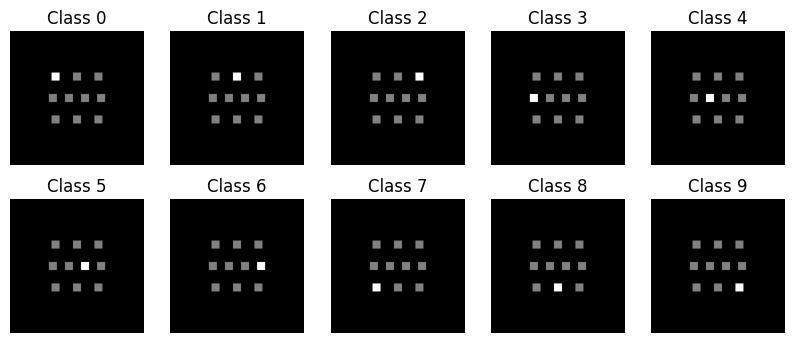

In [6]:
# Create detector segments for each digit class (0-9)
# Each detector has size 6.4λ × 6.4λ as specified in the article

def create_segment_mask(x: int, y: int):
    """Create a detector mask at specified position (x, y)."""
    dx = dy = int(6.4 * wavelength / neuron_size)

    res = torch.zeros((Nx, Ny))
    res[
        (Ny - dy) // 2 + y : (Ny + dy) // 2 + y, (Nx - dx) // 2 + x : (Nx + dx) // 2 + x
    ] = 1.0
    return res


d = int(6.4 * wavelength / neuron_size)

# Create 10 detector masks arranged in a specific pattern
# (matching the detector layout from the article)
detector_segment_masks = torch.stack(
    [
        create_segment_mask(-int(2.7 * d), -int(2.7 * d)),  # Detector for digit 0
        create_segment_mask(0, -int(2.7 * d)),              # Detector for digit 1
        create_segment_mask(int(2.7 * d), -int(2.7 * d)),   # Detector for digit 2
        create_segment_mask(-int(3 * d), 0),                # Detector for digit 3
        create_segment_mask(-int(1 * d), 0),                # Detector for digit 4
        create_segment_mask(int(1 * d), 0),                 # Detector for digit 5
        create_segment_mask(int(3 * d), 0),                 # Detector for digit 6
        create_segment_mask(-int(2.7 * d), int(2.7 * d)),   # Detector for digit 7
        create_segment_mask(0, int(2.7 * d)),               # Detector for digit 8
        create_segment_mask(int(2.7 * d), int(2.7 * d)),    # Detector for digit 9
    ],
    dim=-1,
)


# Visualize the detector layout
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(
        detector_segment_masks[..., i] + torch.sum(detector_segment_masks, axis=-1),
        cmap="gray",
    )
    plt.title(f"Class {i}")
    plt.gca().set_axis_off()
plt.show()

# Convolutional layer

To create convolutional layer, we will use three diffrent kernel types:

In [7]:
# ============================
# Gaussian Kernel
# ============================
def gaussian_kernel(size=9, sigma=1.0):
    ax = torch.arange(-size // 2 + 1., size // 2 + 1.)
    xx, yy = torch.meshgrid(ax, ax, indexing="ij")
    kernel = torch.exp(-(xx**2 + yy**2) / (2. * sigma**2))
    kernel = kernel
    return kernel


# ============================
# Laplacian of Gaussian
# ============================
def laplacian_of_gaussian(size=9, sigma=1.0):
    ax = torch.arange(-size // 2 + 1., size // 2 + 1.)
    xx, yy = torch.meshgrid(ax, ax, indexing="ij")
    norm = (xx**2 + yy**2 - 2 * sigma**2) / (sigma**4)
    kernel = norm * torch.exp(-(xx**2 + yy**2) / (2. * sigma**2))
    kernel = kernel - kernel.mean()
    return kernel


# ============================
# Gabor Filter
# ============================
def gabor_kernel(size=9, sigma=2.0, theta=torch.tensor(0), Lambda=4.0, psi=0, gamma=0.5):
    ax = torch.arange(-size // 2 + 1., size // 2 + 1.)
    xx, yy = torch.meshgrid(ax, ax, indexing="ij")
    x_theta = xx * torch.cos(theta) + yy * torch.sin(theta)
    y_theta = -xx * torch.sin(theta) + yy * torch.cos(theta)
    gb = torch.exp(-0.5 * (x_theta**2 + gamma**2 * y_theta**2) / sigma**2) * \
         torch.cos(2 * torch.pi * x_theta / Lambda + psi)
    return gb


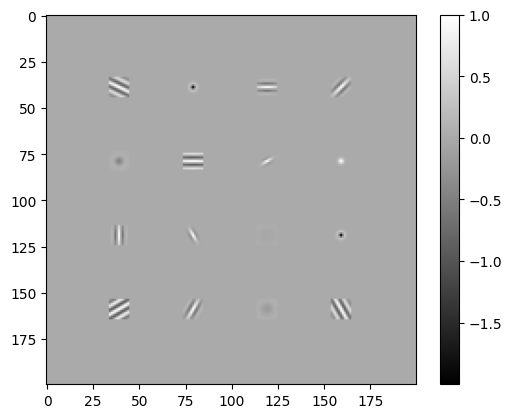

In [22]:
kernel_size = 11
kermels = (
    gabor_kernel(size=kernel_size, sigma=4.0, theta=torch.tensor(-torch.pi / 7)),
    laplacian_of_gaussian(size=kernel_size, sigma=1.0),
    gabor_kernel(size=kernel_size, sigma=2.0, theta=torch.tensor(0)),
    gabor_kernel(size=kernel_size, sigma=2.0, theta=torch.tensor(torch.pi / 4)),
    laplacian_of_gaussian(size=kernel_size, sigma=2.0),
    gabor_kernel(size=kernel_size, sigma=4.0, theta=torch.tensor(0)),
    gabor_kernel(size=kernel_size, sigma=1.0, theta=torch.tensor(torch.pi / 6)),
    gaussian_kernel(size=kernel_size, sigma=1.0),
    gabor_kernel(size=kernel_size, sigma=2.0, theta=torch.tensor(torch.pi / 2)),
    gabor_kernel(size=kernel_size, sigma=1.2, theta=torch.tensor(-torch.pi / 3)),
    laplacian_of_gaussian(size=kernel_size, sigma=5.0),
    laplacian_of_gaussian(size=kernel_size, sigma=1.0),
    gabor_kernel(size=kernel_size, sigma=6.0, theta=torch.tensor(torch.pi / 6)),
    gabor_kernel(size=kernel_size, sigma=2.0, theta=torch.tensor(torch.pi / 3)),
    laplacian_of_gaussian(size=kernel_size, sigma=3.0),
    gabor_kernel(size=kernel_size, sigma=4.0, theta=torch.tensor(-torch.pi / 3)),
)

# Create a convolutional layer mask by placing the kernels in specific regions of the layer
conv_layer_mask = torch.zeros(Ny, Nx)

for i in range(1, 5):
    for j in range(1, 5):
        conv_layer_mask[
            (- kernel_size) // 2 + i * Ny // 5 : (kernel_size) // 2 + (i) * Ny // 5,
            (- kernel_size) // 2 + j * Nx // 5 : (kernel_size) // 2 + (j ) * Nx // 5,
        ] = kermels[(i-1) * 4 + j-1]


plt.imshow(conv_layer_mask, cmap="gray")
plt.colorbar()
plt.show()

## Network

See Figure 2 in [[1]](https://www.mdpi.com/1424-8220/23/12/5749)!

In [9]:
class Model(nn.Module):
    """
    Diffractive Convolutional Neural Networks for MNIST classification.
    
    The architecture consists of:
    - 4f system as an optical convolutional layer
    - 1 diffractive layer with phase-only modulation
    - Free-space propagation between layers (40λ distance)
    - Final propagation to detector plane
    - 10 detectors for digit classification
    """
    
    def __init__(self):
        super().__init__()

        focal_length=20 * wavelength

        elements = [
            sv.elements.FreeSpace(
                simulation_parameters=SIM_PARAMS,
                distance=focal_length,
                method="AS",
            ),
            sv.elements.ThinLens(
                simulation_parameters=SIM_PARAMS,
                focal_length=focal_length,  # Focal length for 4f system
            ),
            sv.elements.FreeSpace(
                simulation_parameters=SIM_PARAMS,
                distance=focal_length,
                method="AS",
            ),
            sv.elements.DiffractiveLayer(
                simulation_parameters=SIM_PARAMS,
                mask=conv_layer_mask,  # Predefined convolutional kernel mask,
                mask_norm=1.0
            ),
            sv.elements.FreeSpace(
                simulation_parameters=SIM_PARAMS,
                distance=focal_length,
                method="AS",
            ),
            sv.elements.ThinLens(
                simulation_parameters=SIM_PARAMS,
                focal_length=focal_length,  # Focal length for 4f system
            ),
            sv.elements.FreeSpace(
                simulation_parameters=SIM_PARAMS,
                distance=focal_length,
                method="AS",
            ),
        ]

        # Create 1 diffractive layers with free-space propagation
        for _ in range(1):
            # Diffractive layer with trainable phase mask
            elements.append(
                sv.elements.DiffractiveLayer(
                    simulation_parameters=SIM_PARAMS,
                    mask=sv.ConstrainedParameter(
                        torch.full((Nx, Ny), torch.pi),  # Initialize with π
                        min_value=0,
                        max_value=2 * torch.pi,  # Phase-only: [0, 2π]
                    ),
                )
            )
            # Free-space propagation using Angular Spectrum method
            elements.append(
                sv.elements.FreeSpace(
                    simulation_parameters=SIM_PARAMS,
                    distance=40 * wavelength,  # Distance between layers: 40λ
                    method="AS",  # Angular Spectrum propagation
                )
            )

        self.setup = sv.LinearOpticalSetup(elements)

    def forward(self, wavefront: sv.Wavefront):
        # Propagate through the optical setup
        wavefront = self.setup(wavefront)
        intensity = wavefront.intensity

        # Calculate total intensity at each detector
        I_l = (intensity[..., None] * detector_segment_masks).sum(dim=(-2, -3))
        
        # Normalize intensities to [0, 10] range (as in the article)
        I_l_norm = I_l / torch.max(I_l, dim=-1, keepdim=True).values * 10
        return I_l_norm

In [10]:
# Instantiate the optical neural network model
model = Model()

In [11]:
# Select an example wavefront from the training data
example_wf = training_data[128][0]

In [12]:
# Visualize the structure of the optical setup
show_structure(model.setup)

In [13]:
# Display specifications of each element in the optical setup
show_specs(model.setup)

In [14]:
# Show step-by-step propagation through the optical network
show_stepwise_forward(model.setup, input=example_wf, simulation_parameters=SIM_PARAMS)

# 4. Training the Network

## 4.1. Training preparation

### DataLoaders

Information from the supplementary material of [[1]](https://www.science.org/doi/suppl/10.1126/science.aat8084/suppl_file/aat8084-lin-sm-rev-3.pdf) for MNIST classification:

> The training batch size was set to be $8$...

> For this task, phase-only transmission masks were designed by training a five-layer $D^2NN$ with $55,000$ images ($5,000$ validation images) from the MNIST (Modified National Institute of Standards and Technology) handwritten digit database.


We will use training dataset for training and test dataset for testing, provided with `torchvision.datasets.MNIST`.
We will use batch size of 128 to speed up the training process.

In [15]:
# Create data loaders for training and testing
batch_size = 128

train_dataloader = torch.utils.data.DataLoader(
    training_data,
    batch_size=batch_size,
    shuffle=True,  # Shuffle training data
    # num_workers=2,  # Uncomment for parallel data loading
    drop_last=False,
)

test_dataloader = torch.utils.data.DataLoader(
    test_data,
    batch_size=128,
    shuffle=False,  # Don't shuffle test data
    # num_workers=2,  # Uncomment for parallel data loading
    drop_last=False,
)

### Optimizer and Loss Function

Information from the supplementary material of [[1]](https://www.science.org/doi/suppl/10.1126/science.aat8084/suppl_file/aat8084-lin-sm-rev-3.pdf) for MNIST classification:

> We used the stochastic gradient descent algorithm, Adam, to back-propagate the errors and update the layers of the network to minimize the loss function.

Additional information from [[2]](https://ieeexplore.ieee.org/abstract/document/8732486):
> ... a back-propagation method by applying the adaptive moment estimation optimizer (Adam) with a learning rate of $10^{−3}$

We will use the Adam optimizer with a learning rate of `5e-3` to speed up the training process.

In [16]:
# Set up optimizer and loss function
optimizer = torch.optim.Adam(params=model.parameters(), lr=5e-3)
loss_fn = nn.CrossEntropyLoss()

### Training and evaluation loops

The training loops are direct copy of those presented at torch [documentation](https://docs.pytorch.org/tutorials/beginner/basics/optimization_tutorial.html).

In [17]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.train()
    
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        # Print progress every 100 batches
        if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")


def test_loop(dataloader, model, loss_fn):
    # Set the model to evaluation mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # Also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(
        f"Test Error: \n Accuracy: {(100 * correct):>0.1f}%, Avg loss: {test_loss:>8f} \n"
    )
    return correct, test_loss

## 4.2 Training and Evaluating

In [18]:
# Track training progress
test_accuracies = []
test_losses = []

# Evaluate the model before training (random initialization)
accuracy, loss = test_loop(test_dataloader, model, loss_fn)
test_accuracies.append(accuracy)
test_losses.append(loss)

# Train the model for specified number of epochs
epochs = 2
for t in range(epochs):
    print(f"Epoch {t + 1}\n-------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer)
    accuracy, loss = test_loop(test_dataloader, model, loss_fn)
    test_accuracies.append(accuracy)
    test_losses.append(loss)

print("Done!")

Test Error: 
 Accuracy: 13.2%, Avg loss: 8.135609 

Epoch 1
-------------------------------
loss: 8.390922  [  128/60000]
loss: 4.463055  [12928/60000]
loss: 1.318618  [25728/60000]
loss: 0.869712  [38528/60000]
loss: 0.643426  [51328/60000]
Test Error: 
 Accuracy: 81.7%, Avg loss: 0.595821 

Epoch 2
-------------------------------
loss: 0.603160  [  128/60000]
loss: 0.612661  [12928/60000]
loss: 0.578010  [25728/60000]
loss: 0.523947  [38528/60000]
loss: 0.473807  [51328/60000]
Test Error: 
 Accuracy: 87.9%, Avg loss: 0.436734 

Done!


### Learning Curves (Cross-Entropy Loss and Accuracy)

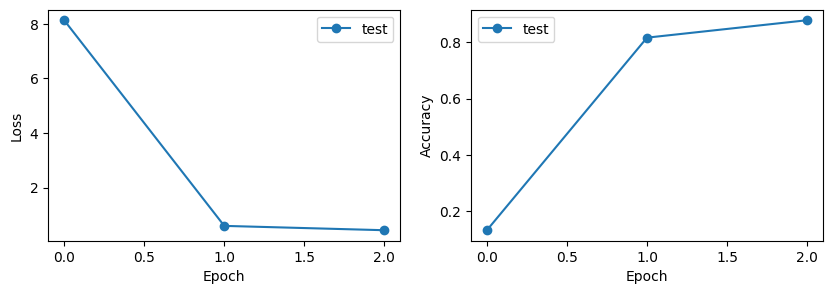

In [19]:
# Plot learning curves to visualize training progress
fig, axs = plt.subplots(1, 2, figsize=(10, 3))

# Loss curve
axs[0].plot(range(epochs + 1), test_losses, "-o", label="test")
axs[0].set_ylabel("Loss")
axs[0].set_xlabel("Epoch")
axs[0].legend()

# Accuracy curve
axs[1].plot(range(epochs + 1), test_accuracies, "-o", label="test")
axs[1].set_ylabel("Accuracy")
axs[1].set_xlabel("Epoch")
axs[1].legend()

plt.show()

### Trained Phase Masks

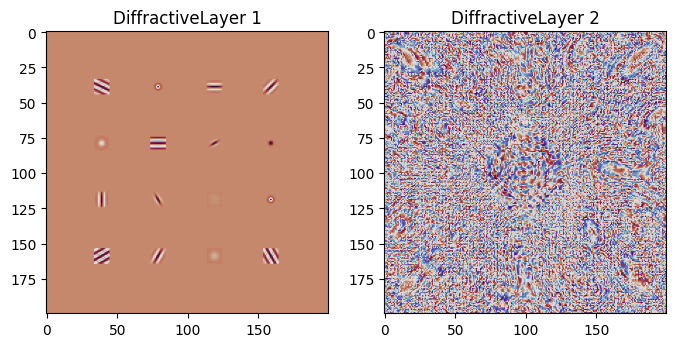

In [20]:
# Extract and visualize the convolutional layer phase mask and trained phase mask
diffractive_layers = [
    element
    for element in model.setup.elements
    if isinstance(element, sv.elements.DiffractiveLayer)
]

fig, axs = plt.subplots(1, 2, figsize=(8, 4))

for ind_layer, layer in enumerate(diffractive_layers):
    plt.subplot(1, 2, ind_layer + 1)
    trained_mask = layer.mask.detach()

    plt.imshow(trained_mask, cmap="twilight_shifted")
    plt.title(f"DiffractiveLayer {ind_layer + 1}")
plt.show()

# 5. Example of Classification

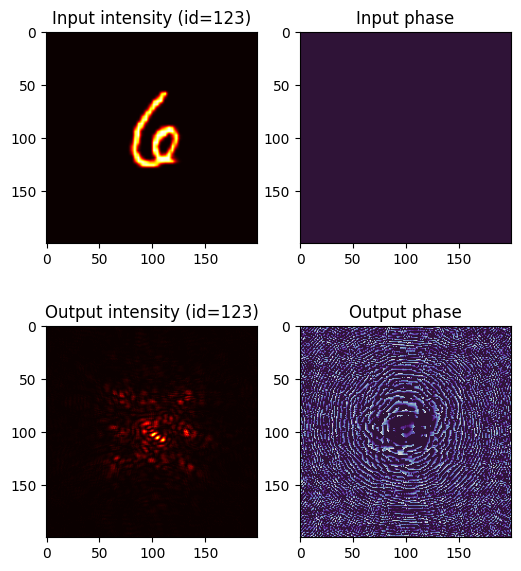

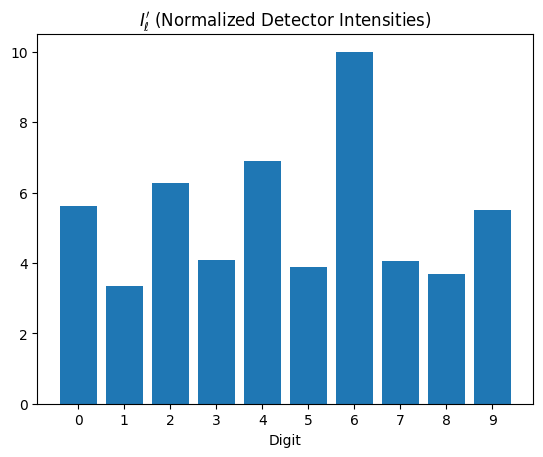

In [21]:
# Select a test sample and visualize the classification process
ind_test = 123

plt.figure(figsize=(6, 7))

test_wavefront, test_target = test_data[ind_test]

# Show input wavefront
plt.subplot(2, 2, 1)
plt.title(f"Input intensity (id={ind_test})")
plt.imshow(test_wavefront.intensity, cmap="hot")

plt.subplot(2, 2, 2)
plt.title("Input phase")
plt.imshow(test_wavefront.angle(), cmap="twilight_shifted", vmin=0, vmax=2 * torch.pi)

# Propagate through the optical network
with torch.no_grad():
    test_wavefront_out = model.setup(sv.Wavefront(test_wavefront))

    # Show output wavefront
    plt.subplot(2, 2, 3)
    plt.title(f"Output intensity (id={ind_test})")
    plt.imshow(test_wavefront_out.intensity, cmap="hot")

    plt.subplot(2, 2, 4)
    plt.title("Output phase")
    plt.imshow(test_wavefront_out.angle(), cmap="twilight_shifted", vmin=0, vmax=2 * torch.pi)

plt.show()


# Display detector responses (classification scores)
with torch.no_grad():
    classes = list(range(10))
    plt.bar(classes, model(sv.Wavefront(test_wavefront)))
    plt.xticks(classes)
    plt.xlabel("Digit")
    plt.title("$I_\ell'$ (Normalized Detector Intensities)")
    
    plt.show()